**MOUNT DRIVE**

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
!ls "/content/drive/MyDrive/Colab Notebooks/archive/Training"

glioma	meningioma  notumor  pituitary


**IMPOR + CEK DEVICE**

In [14]:
import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from PIL import Image
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score,
    classification_report
)

# ── Device ──────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


**KONFIGURASI**

In [15]:
# ── Paths ────────────────────────────────────────────────────────────────────
TRAIN_PATH = "/content/drive/MyDrive/Colab Notebooks/archive/Training"
TEST_PATH  = "/content/drive/MyDrive/Colab Notebooks/archive/Testing"

# ── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE         = 224   # EfficientNetB3 & VGG16
IMG_SIZE_INCEPTION = 299  # InceptionV3 minimum requirement
BATCH_SIZE      = 32
NUM_CLASSES     = 4
EPOCHS_PHASE1   = 10        # frozen backbone
EPOCHS_PHASE2   = 10        # fine-tuning
LR_PHASE1       = 1e-3
LR_PHASE2       = 1e-5
SEED            = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

CLASS_NAMES = sorted(os.listdir(TRAIN_PATH))   # ['glioma','meningioma','notumor','pituitary']
print("Classes:", CLASS_NAMES)

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


**MENGECEK ISI DATASET**

In [16]:
def build_dataframe(root_path):
    """Walk class subdirectories, return DataFrame with img_path and label columns."""
    records = []
    for cls in os.listdir(root_path):
        cls_dir = os.path.join(root_path, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in os.listdir(cls_dir):
            records.append({"img_path": os.path.join(cls_dir, fname), "label": cls})
    return pd.DataFrame(records)


train_df = build_dataframe(TRAIN_PATH)
test_df  = build_dataframe(TEST_PATH)

print(f"Train samples : {len(train_df)}")
print(f"Test  samples : {len(test_df)}")
print("\nClass distribution:")
print(pd.DataFrame([train_df.label.value_counts(), test_df.label.value_counts()],
                   index=["Train", "Test"]))

Train samples : 5600
Test  samples : 1600

Class distribution:
label  pituitary  meningioma  glioma  notumor
Train       1400        1400    1400     1400
Test         400         400     400      400


In [17]:
# ── Transforms ───────────────────────────────────────────────────────────────
# ImageNet normalisation statistics — same as the original Keras rescale + BN stats
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

#For the Inception model
inception_transforms_train = transforms.Compose([
    transforms.Resize((IMG_SIZE_INCEPTION, IMG_SIZE_INCEPTION)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

inception_transforms_test = transforms.Compose([
    transforms.Resize((IMG_SIZE_INCEPTION, IMG_SIZE_INCEPTION)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

**KUSTOMISASI DATASET**

In [18]:
# ── Custom Dataset ────────────────────────────────────────────────────────────
class BrainTumorDataset(Dataset):
    def __init__(self, dataframe, class_names, transform=None):
        self.df          = dataframe.reset_index(drop=True)
        self.class_names = class_names
        self.label_map   = {c: i for i, c in enumerate(class_names)}
        self.transform   = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row["img_path"]).convert("RGB")
        label = self.label_map[row["label"]]
        if self.transform:
            image = self.transform(image)
        return image, label


#DataLoader for EfficientNetB0 and VGG16
train_dataset = BrainTumorDataset(train_df, CLASS_NAMES, train_transforms)
test_dataset  = BrainTumorDataset(test_df,  CLASS_NAMES, test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

#DataLoader for the Inception model
inception_train_dataset = BrainTumorDataset(train_df, CLASS_NAMES, inception_transforms_train)
inception_test_dataset  = BrainTumorDataset(test_df,  CLASS_NAMES, inception_transforms_test)

inception_train_loader = DataLoader(inception_train_dataset, batch_size=BATCH_SIZE,
                                    shuffle=True,  num_workers=2, pin_memory=True)
inception_test_loader  = DataLoader(inception_test_dataset,  batch_size=BATCH_SIZE,
                                    shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Test  batches: {len(test_loader)}")

Train batches: 175
Test  batches: 50


**MENAMPILKAN SAMPEL**

Training samples:


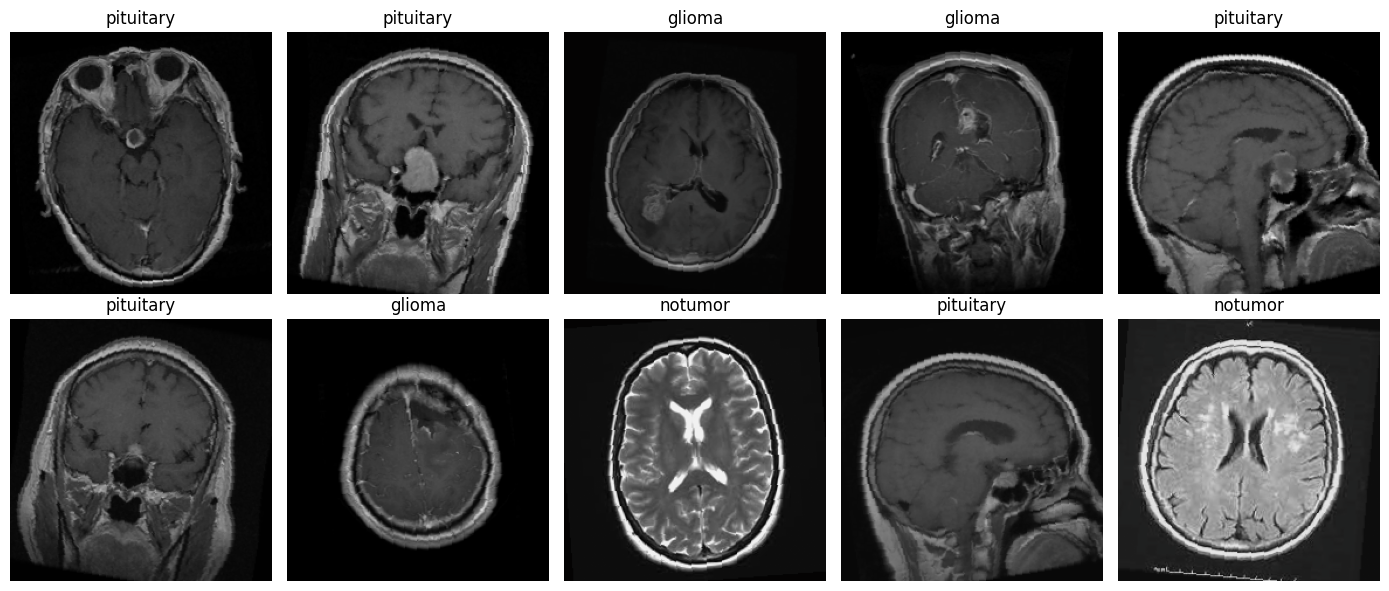

Testing samples:


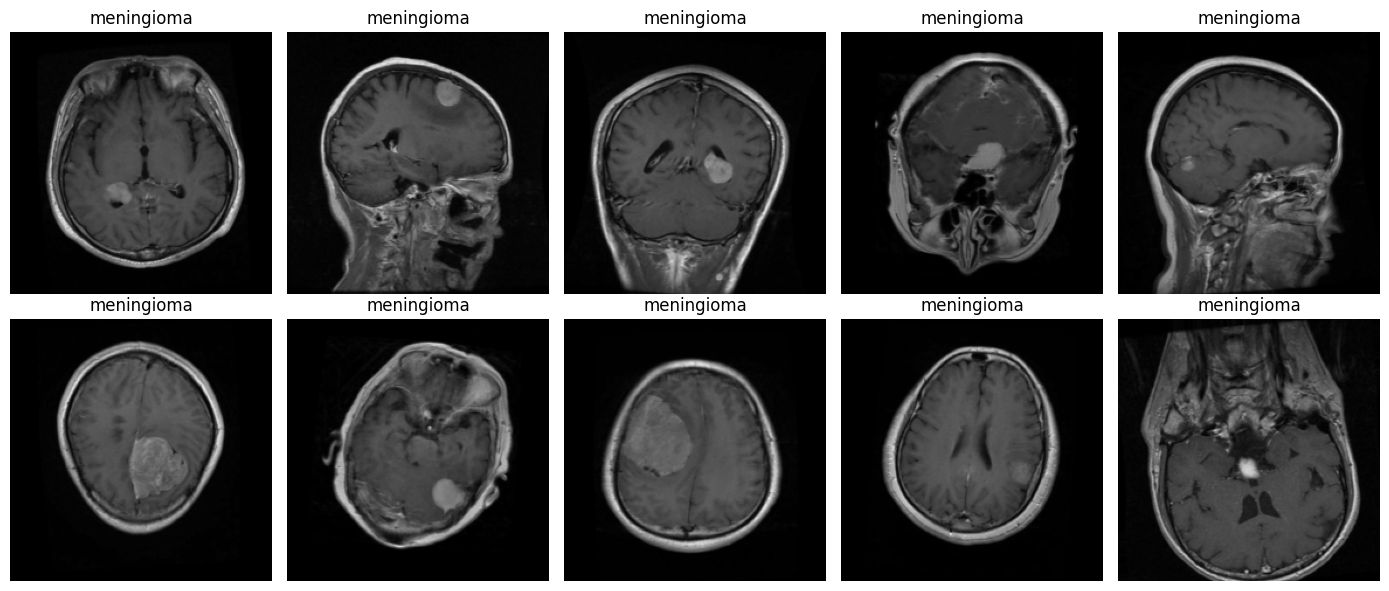

In [19]:
def show_samples(loader, class_names, n=10):
    """Show n sample images from a DataLoader with their class labels."""
    images, labels = next(iter(loader))
    # Un-normalise for display
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    imgs = (images[:n] * std + mean).clamp(0, 1).permute(0, 2, 3, 1).numpy()

    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(imgs[i])
        ax.set_title(class_names[labels[i]])
        ax.axis("off")
    plt.tight_layout()
    plt.show()


print("Training samples:")
show_samples(train_loader, CLASS_NAMES)
print("Testing samples:")
show_samples(test_loader, CLASS_NAMES)

**TRAINING DAN EVALUASI**

In [20]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct  += (preds == labels).sum().item()
        total    += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct  += (preds == labels).sum().item()
        total    += labels.size(0)
    return running_loss / total, correct / total


def train_model(model, train_loader, test_loader, criterion, optimizer,
                epochs, device, model_name="Model"):
    """Full training loop. Returns history dict."""
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_acc   = 0.0
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        va_loss, va_acc = evaluate(model, test_loader, criterion, device)
        elapsed = time.time() - t0

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if va_acc > best_acc:
            best_acc   = va_acc
            best_state = copy.deepcopy(model.state_dict())

        print(f"[{model_name}] Epoch {epoch:02d}/{epochs}  "
              f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  "
              f"val_loss={va_loss:.4f}  val_acc={va_acc:.4f}  "
              f"({elapsed:.1f}s)")

    # Restore best weights
    model.load_state_dict(best_state)
    print(f"\n✅  Best val accuracy: {best_acc:.4f}")
    return history


def plot_history(history, model_name="Model"):
    """Plot training/validation loss and accuracy curves."""
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, history["train_loss"], label="Train Loss", color="red")
    axes[0].plot(epochs, history["val_loss"],   label="Val Loss",   color="green")
    axes[0].set_title(f"{model_name} – Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Train Acc", color="red")
    axes[1].plot(epochs, history["val_acc"],   label="Val Acc",   color="green")
    axes[1].set_title(f"{model_name} – Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(model, loader, class_names, device, model_name="Model"):
    """Run full inference on loader and plot confusion matrix."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images.to(device))
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{model_name} – Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    print(classification_report(all_labels, all_preds, target_names=class_names))
    return all_labels, all_preds



**MODEL**

In [21]:
def freeze_backbone(model, arch):
    """Freeze all backbone parameters; only the classification head will train."""
    if arch == "efficientnet_b3":
        for param in model.features.parameters():
            param.requires_grad = False
    elif arch == "vgg16":
        for param in model.features.parameters():
            param.requires_grad = False
    elif arch == "inception_v3":
        for name, param in model.named_parameters():
            if "fc" not in name and "AuxLogits" not in name:
                param.requires_grad = False


def unfreeze_for_finetune(model, arch):
    """Unfreeze selected deep layers for fine-tuning at a lower LR."""
    if arch == "efficientnet_b3":
        # Unfreeze the last 2 MBConv blocks (blocks 6 & 7) + classifier
        for param in model.parameters():
            param.requires_grad = False
        for name, param in model.named_parameters():
            if "features.6" in name or "features.7" in name or "classifier" in name:
                param.requires_grad = True

    elif arch == "vgg16":
        # Unfreeze the last conv block (features[24:]) + classifier
        for param in model.parameters():
            param.requires_grad = False
        for name, param in model.named_parameters():
            if "features.24" in name or "features.26" in name or "features.28" in name \
               or "classifier" in name:
                param.requires_grad = True

    elif arch == "inception_v3":
        # Unfreeze Mixed_7a, Mixed_7b, Mixed_7c + fc
        for param in model.parameters():
            param.requires_grad = False
        for name, param in model.named_parameters():
            if "Mixed_7" in name or "fc" in name:
                param.requires_grad = True


def build_model(arch, num_classes, freeze=True):
    """
    Load a torchvision pretrained backbone, replace the classifier head,
    optionally freeze the backbone.

    Returns: model (moved to DEVICE)
    """
    if arch == "efficientnet_b3":
        model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, num_classes)
        )

    elif arch == "vgg16":
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(in_features, num_classes)
        # Add dropout before the new head for regularisation
        model.classifier = nn.Sequential(
            *list(model.classifier.children())[:-1],  # keep original fc6 & fc7 + relus/drops
            nn.Dropout(p=0.4),
            nn.Linear(4096, num_classes)
        )

    elif arch == "inception_v3":
        # aux_logits=True is kept during training (provides gradient regularisation)
        model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1,
                                     aux_logits=True)
        model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, num_classes)
        model.fc           = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(model.fc.in_features, num_classes)
        )
    else:
        raise ValueError(f"Unknown arch: {arch}")

    if freeze:
        freeze_backbone(model, arch)

    return model.to(DEVICE)


def count_trainable_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"Trainable params : {trainable:,}  /  Total: {total:,}  "
          f"({100*trainable/total:.1f}%)")

*Model 1 — EfficientNetB3*

ekstraksi fitur

Trainable params : 6,148  /  Total: 10,702,380  (0.1%)

── EfficientNetB3 Phase 1: Feature Extraction ──
[EfficientNetB3-P1] Epoch 01/10  train_loss=0.7642  train_acc=0.7338  val_loss=0.6718  val_acc=0.7706  (61.3s)
[EfficientNetB3-P1] Epoch 02/10  train_loss=0.5203  train_acc=0.8209  val_loss=0.6172  val_acc=0.7894  (56.8s)
[EfficientNetB3-P1] Epoch 03/10  train_loss=0.4779  train_acc=0.8252  val_loss=0.5854  val_acc=0.8050  (57.6s)
[EfficientNetB3-P1] Epoch 04/10  train_loss=0.4484  train_acc=0.8402  val_loss=0.6395  val_acc=0.8181  (58.3s)
[EfficientNetB3-P1] Epoch 05/10  train_loss=0.4285  train_acc=0.8405  val_loss=0.5642  val_acc=0.8163  (57.8s)
[EfficientNetB3-P1] Epoch 06/10  train_loss=0.4147  train_acc=0.8418  val_loss=1.4411  val_acc=0.8225  (59.3s)
[EfficientNetB3-P1] Epoch 07/10  train_loss=0.4240  train_acc=0.8396  val_loss=0.6486  val_acc=0.8113  (60.0s)
[EfficientNetB3-P1] Epoch 08/10  train_loss=0.4109  train_acc=0.8470  val_loss=0.7866  val_acc=0.8219  (61.2s)
[Effici

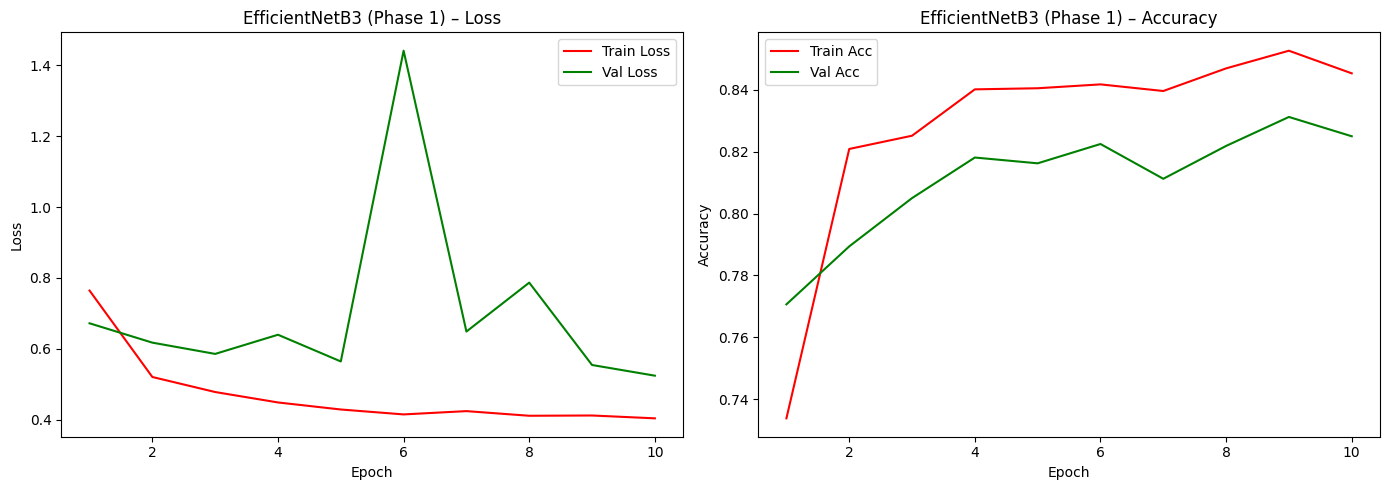

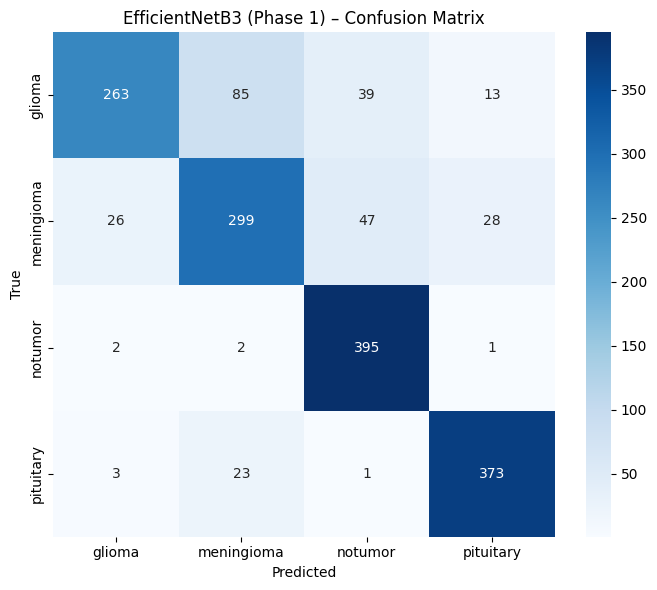

              precision    recall  f1-score   support

      glioma       0.89      0.66      0.76       400
  meningioma       0.73      0.75      0.74       400
     notumor       0.82      0.99      0.90       400
   pituitary       0.90      0.93      0.92       400

    accuracy                           0.83      1600
   macro avg       0.84      0.83      0.83      1600
weighted avg       0.84      0.83      0.83      1600



In [22]:
efficientnet = build_model("efficientnet_b3", NUM_CLASSES, freeze=True)
count_trainable_params(efficientnet)

criterion_eff = nn.CrossEntropyLoss()
optimizer_eff = optim.Adam(
    filter(lambda p: p.requires_grad, efficientnet.parameters()),
    lr=LR_PHASE1
)

#DEVICE1 = torch.device("cpu")

print("\n── EfficientNetB3 Phase 1: Feature Extraction ──")
eff_history_p1 = train_model(
    efficientnet, train_loader, test_loader,
    criterion_eff, optimizer_eff,
    EPOCHS_PHASE1, DEVICE, model_name="EfficientNetB3-P1"
)
plot_history(eff_history_p1, model_name="EfficientNetB3 (Phase 1)")
_ = plot_confusion_matrix(efficientnet, test_loader, CLASS_NAMES, DEVICE,
                           model_name="EfficientNetB3 (Phase 1)")

Phase 2 — Fine-Tuning (last 2 blocks unfrozen)

Trainable params : 7,919,330  /  Total: 10,702,380  (74.0%)

── EfficientNetB3 Phase 2: Fine-Tuning ──
[EfficientNetB3-P2] Epoch 01/10  train_loss=0.3712  train_acc=0.8630  val_loss=1.6054  val_acc=0.8406  (63.6s)
[EfficientNetB3-P2] Epoch 02/10  train_loss=0.3595  train_acc=0.8614  val_loss=0.7332  val_acc=0.8375  (62.8s)
[EfficientNetB3-P2] Epoch 03/10  train_loss=0.3422  train_acc=0.8752  val_loss=1.0911  val_acc=0.8544  (64.4s)
[EfficientNetB3-P2] Epoch 04/10  train_loss=0.3175  train_acc=0.8800  val_loss=0.5629  val_acc=0.8506  (62.7s)
[EfficientNetB3-P2] Epoch 05/10  train_loss=0.2943  train_acc=0.8927  val_loss=0.7766  val_acc=0.8638  (62.6s)
[EfficientNetB3-P2] Epoch 06/10  train_loss=0.2774  train_acc=0.8932  val_loss=0.7055  val_acc=0.8681  (63.2s)
[EfficientNetB3-P2] Epoch 07/10  train_loss=0.2676  train_acc=0.9011  val_loss=2.2927  val_acc=0.8731  (63.1s)
[EfficientNetB3-P2] Epoch 08/10  train_loss=0.2472  train_acc=0.9050  val_loss=0.7949  val_acc=0.8788  (61.3s)
[Efficien

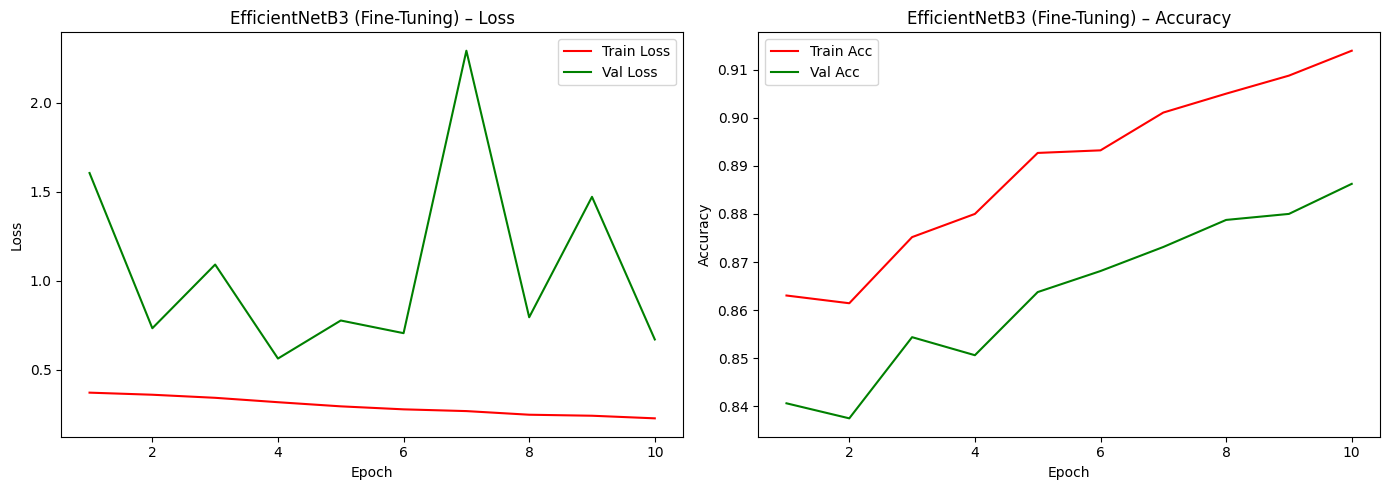

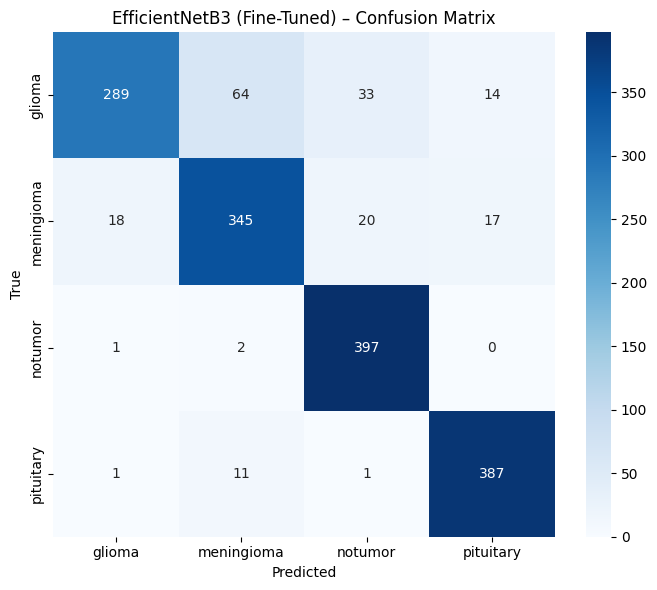

              precision    recall  f1-score   support

      glioma       0.94      0.72      0.82       400
  meningioma       0.82      0.86      0.84       400
     notumor       0.88      0.99      0.93       400
   pituitary       0.93      0.97      0.95       400

    accuracy                           0.89      1600
   macro avg       0.89      0.89      0.88      1600
weighted avg       0.89      0.89      0.88      1600



In [23]:
unfreeze_for_finetune(efficientnet, "efficientnet_b3")
count_trainable_params(efficientnet)

optimizer_eff_ft = optim.Adam(
    filter(lambda p: p.requires_grad, efficientnet.parameters()),
    lr=LR_PHASE2
)

print("\n── EfficientNetB3 Phase 2: Fine-Tuning ──")
eff_history_p2 = train_model(
    efficientnet, train_loader, test_loader,
    criterion_eff, optimizer_eff_ft,
    EPOCHS_PHASE2, DEVICE, model_name="EfficientNetB3-P2"
)
plot_history(eff_history_p2, model_name="EfficientNetB3 (Fine-Tuning)")
eff_labels, eff_preds = plot_confusion_matrix(
    efficientnet, test_loader, CLASS_NAMES, DEVICE,
    model_name="EfficientNetB3 (Fine-Tuned)"
)

*Model 2 — VGG16*


Phase 1 — Feature Extraction

Trainable params : 119,562,244  /  Total: 134,276,932  (89.0%)

── VGG16 Phase 1: Feature Extraction ──
[VGG16-P1] Epoch 01/10  train_loss=0.9526  train_acc=0.7221  val_loss=1.8084  val_acc=0.6987  (66.5s)
[VGG16-P1] Epoch 02/10  train_loss=0.7844  train_acc=0.8107  val_loss=0.9432  val_acc=0.8219  (64.8s)
[VGG16-P1] Epoch 03/10  train_loss=0.7072  train_acc=0.8395  val_loss=0.8350  val_acc=0.8369  (66.1s)
[VGG16-P1] Epoch 04/10  train_loss=0.6460  train_acc=0.8511  val_loss=0.8179  val_acc=0.8400  (67.5s)
[VGG16-P1] Epoch 05/10  train_loss=0.6032  train_acc=0.8527  val_loss=0.6385  val_acc=0.8519  (65.9s)
[VGG16-P1] Epoch 06/10  train_loss=0.5143  train_acc=0.8698  val_loss=1.3019  val_acc=0.8187  (67.1s)
[VGG16-P1] Epoch 07/10  train_loss=0.5438  train_acc=0.8804  val_loss=0.5970  val_acc=0.8731  (65.2s)
[VGG16-P1] Epoch 08/10  train_loss=0.4761  train_acc=0.8782  val_loss=1.0075  val_acc=0.8519  (67.6s)
[VGG16-P1] Epoch 09/10  train_loss=0.4606  train_acc=0.8864  val_loss=0.7513  va

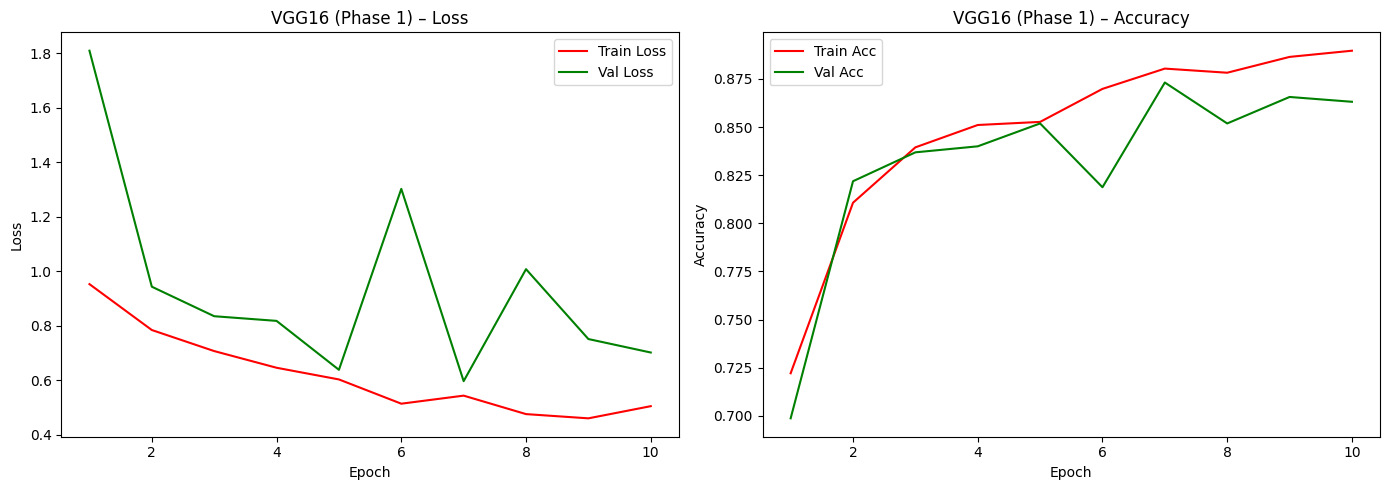

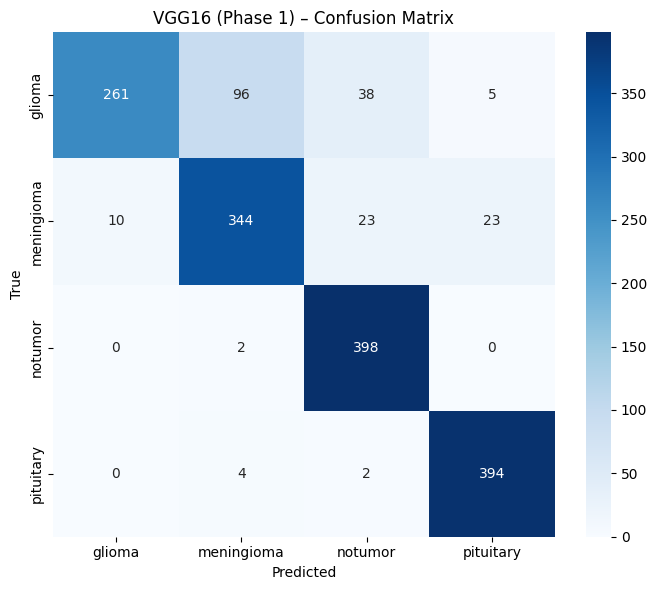

              precision    recall  f1-score   support

      glioma       0.96      0.65      0.78       400
  meningioma       0.77      0.86      0.81       400
     notumor       0.86      0.99      0.92       400
   pituitary       0.93      0.98      0.96       400

    accuracy                           0.87      1600
   macro avg       0.88      0.87      0.87      1600
weighted avg       0.88      0.87      0.87      1600



In [24]:
vgg16 = build_model("vgg16", NUM_CLASSES, freeze=True)
count_trainable_params(vgg16)

criterion_vgg = nn.CrossEntropyLoss()
optimizer_vgg = optim.Adam(
    filter(lambda p: p.requires_grad, vgg16.parameters()),
    lr=LR_PHASE1
)

print("\n── VGG16 Phase 1: Feature Extraction ──")
vgg_history_p1 = train_model(
    vgg16, train_loader, test_loader,
    criterion_vgg, optimizer_vgg,
    EPOCHS_PHASE1, DEVICE, model_name="VGG16-P1"
)
plot_history(vgg_history_p1, model_name="VGG16 (Phase 1)")
_ = plot_confusion_matrix(vgg16, test_loader, CLASS_NAMES, DEVICE,
                           model_name="VGG16 (Phase 1)")

Phase 2 — Fine-Tuning (last conv block unfrozen)

Trainable params : 126,641,668  /  Total: 134,276,932  (94.3%)

── VGG16 Phase 2: Fine-Tuning ──
[VGG16-P2] Epoch 01/10  train_loss=0.3029  train_acc=0.9096  val_loss=0.5156  val_acc=0.8819  (69.0s)
[VGG16-P2] Epoch 02/10  train_loss=0.2410  train_acc=0.9213  val_loss=0.4357  val_acc=0.8862  (70.1s)
[VGG16-P2] Epoch 03/10  train_loss=0.2196  train_acc=0.9259  val_loss=0.4654  val_acc=0.8900  (67.5s)
[VGG16-P2] Epoch 04/10  train_loss=0.1797  train_acc=0.9387  val_loss=0.4905  val_acc=0.8894  (69.8s)
[VGG16-P2] Epoch 05/10  train_loss=0.1640  train_acc=0.9414  val_loss=0.3966  val_acc=0.8988  (71.3s)
[VGG16-P2] Epoch 06/10  train_loss=0.1494  train_acc=0.9495  val_loss=0.4510  val_acc=0.8981  (69.2s)
[VGG16-P2] Epoch 07/10  train_loss=0.1285  train_acc=0.9523  val_loss=0.4488  val_acc=0.9012  (69.1s)
[VGG16-P2] Epoch 08/10  train_loss=0.1228  train_acc=0.9587  val_loss=0.4591  val_acc=0.9019  (66.5s)
[VGG16-P2] Epoch 09/10  train_loss=0.1061  train_acc=0.9627  val_loss=0.4206  val_acc=0

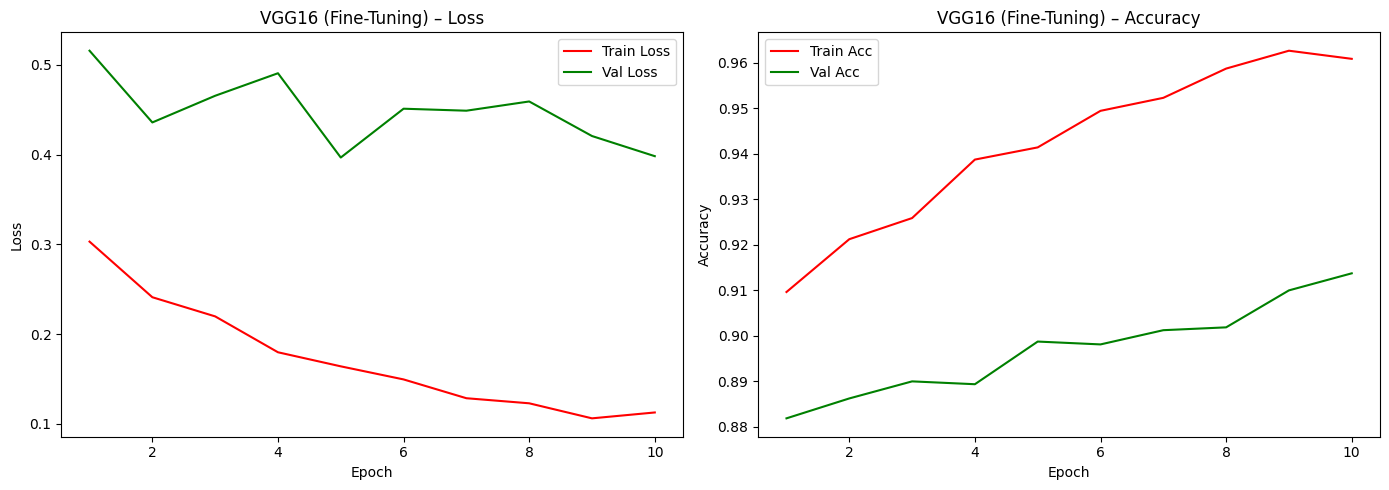

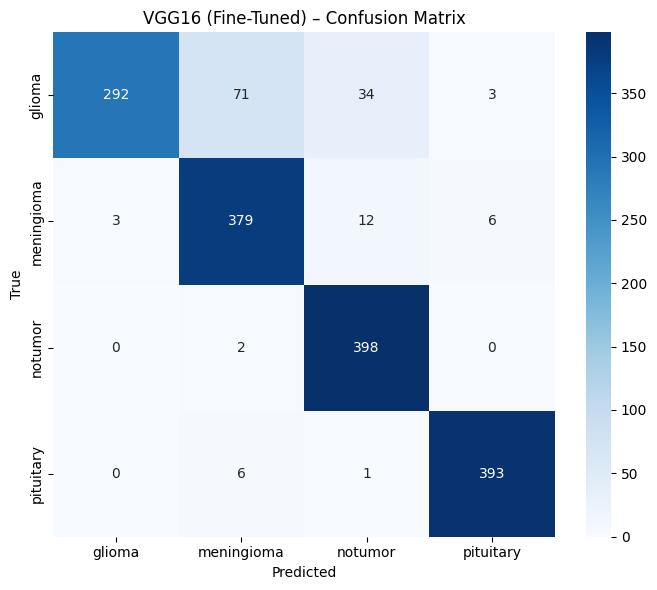

              precision    recall  f1-score   support

      glioma       0.99      0.73      0.84       400
  meningioma       0.83      0.95      0.88       400
     notumor       0.89      0.99      0.94       400
   pituitary       0.98      0.98      0.98       400

    accuracy                           0.91      1600
   macro avg       0.92      0.91      0.91      1600
weighted avg       0.92      0.91      0.91      1600



In [25]:
unfreeze_for_finetune(vgg16, "vgg16")
count_trainable_params(vgg16)

optimizer_vgg_ft = optim.Adam(
    filter(lambda p: p.requires_grad, vgg16.parameters()),
    lr=LR_PHASE2
)

print("\n── VGG16 Phase 2: Fine-Tuning ──")
vgg_history_p2 = train_model(
    vgg16, train_loader, test_loader,
    criterion_vgg, optimizer_vgg_ft,
    EPOCHS_PHASE2, DEVICE, model_name="VGG16-P2"
)
plot_history(vgg_history_p2, model_name="VGG16 (Fine-Tuning)")
vgg_labels, vgg_preds = plot_confusion_matrix(
    vgg16, test_loader, CLASS_NAMES, DEVICE,
    model_name="VGG16 (Fine-Tuned)"
)


*Model 3 — InceptionV3*

In [26]:
# ── Inception-specific training loop ─────────────────────────────────────────
def train_one_epoch_inception(model, loader, criterion, optimizer, device):
    """InceptionV3 returns (main_output, aux_output) in training mode."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        # During training, torchvision Inception returns InceptionOutputs(logits, aux_logits)
        if isinstance(outputs, tuple):
            main_out, aux_out = outputs
            loss = criterion(main_out, labels) + 0.4 * criterion(aux_out, labels)
        else:
            main_out = outputs
            loss = criterion(main_out, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(main_out, 1)
        correct  += (preds == labels).sum().item()
        total    += labels.size(0)
    return running_loss / total, correct / total


def train_model_inception(model, inception_train_loader, inception_test_loader, criterion, optimizer,
                           epochs, device, model_name="InceptionV3"):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_acc   = 0.0
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch_inception(model, inception_train_loader, criterion, optimizer, device)
        va_loss, va_acc = evaluate(model, inception_test_loader, criterion, device)  # eval mode: no aux
        elapsed = time.time() - t0

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if va_acc > best_acc:
            best_acc   = va_acc
            best_state = copy.deepcopy(model.state_dict())

        print(f"[{model_name}] Epoch {epoch:02d}/{epochs}  "
              f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  "
              f"val_loss={va_loss:.4f}  val_acc={va_acc:.4f}  "
              f"({elapsed:.1f}s)")

    model.load_state_dict(best_state)
    print(f"\n✅  Best val accuracy: {best_acc:.4f}")
    return history


Phase 1 — Feature Extraction

Trainable params : 2,568,968  /  Total: 24,354,536  (10.5%)

── InceptionV3 Phase 1: Feature Extraction ──
[InceptionV3-P1] Epoch 01/10  train_loss=0.9792  train_acc=0.6691  val_loss=0.6696  val_acc=0.7600  (76.2s)
[InceptionV3-P1] Epoch 02/10  train_loss=0.6780  train_acc=0.7709  val_loss=0.6049  val_acc=0.7794  (77.4s)
[InceptionV3-P1] Epoch 03/10  train_loss=0.6180  train_acc=0.7854  val_loss=0.5926  val_acc=0.8025  (78.0s)
[InceptionV3-P1] Epoch 04/10  train_loss=0.5679  train_acc=0.7996  val_loss=0.5365  val_acc=0.8113  (76.8s)
[InceptionV3-P1] Epoch 05/10  train_loss=0.5535  train_acc=0.7996  val_loss=0.5736  val_acc=0.8013  (77.2s)
[InceptionV3-P1] Epoch 06/10  train_loss=0.5553  train_acc=0.7998  val_loss=0.5491  val_acc=0.8137  (77.1s)
[InceptionV3-P1] Epoch 07/10  train_loss=0.5530  train_acc=0.7898  val_loss=0.5782  val_acc=0.8037  (76.7s)
[InceptionV3-P1] Epoch 08/10  train_loss=0.5373  train_acc=0.8080  val_loss=0.5975  val_acc=0.7975  (77.1s)
[InceptionV3-P1] Epoch 09/10 

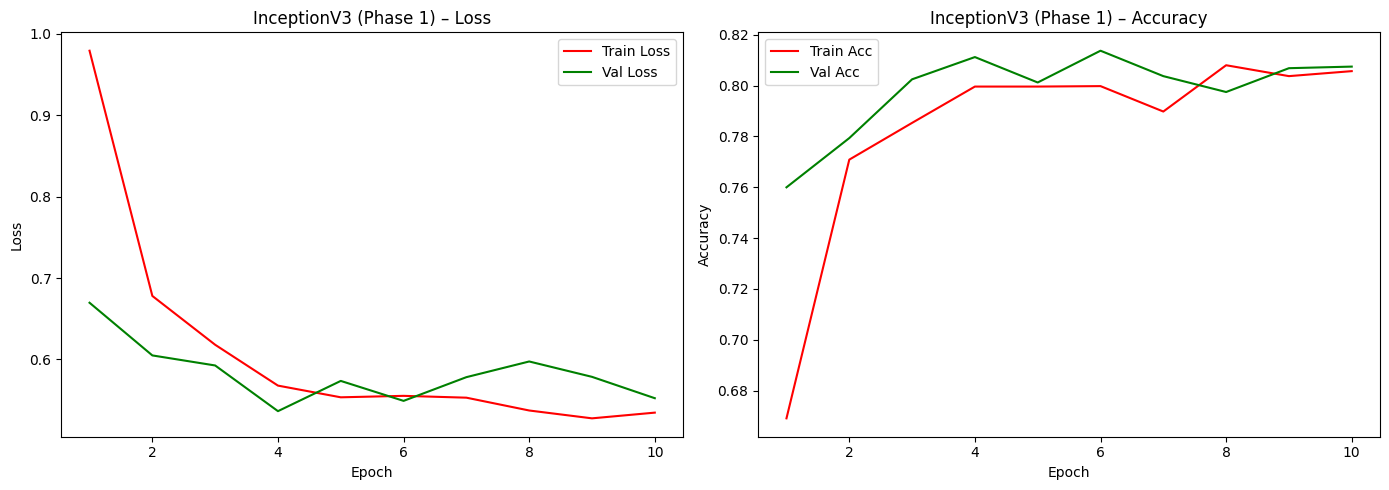

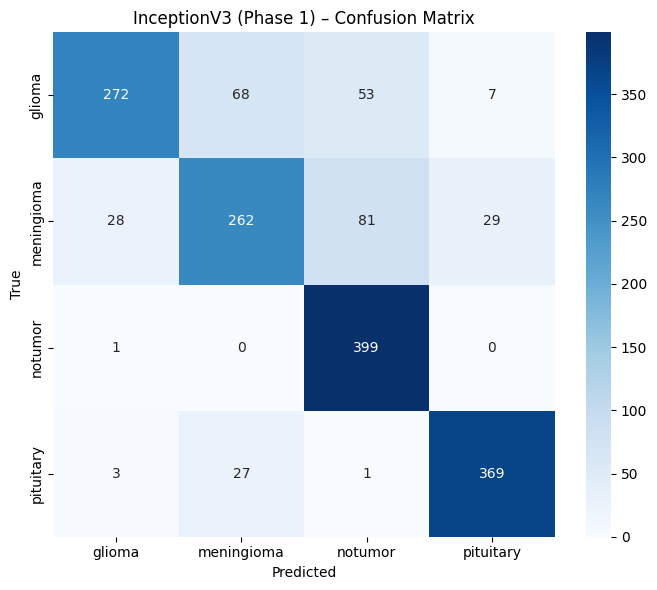

              precision    recall  f1-score   support

      glioma       0.89      0.68      0.77       400
  meningioma       0.73      0.66      0.69       400
     notumor       0.75      1.00      0.85       400
   pituitary       0.91      0.92      0.92       400

    accuracy                           0.81      1600
   macro avg       0.82      0.81      0.81      1600
weighted avg       0.82      0.81      0.81      1600



In [27]:
inception = build_model("inception_v3", NUM_CLASSES, freeze=True)
count_trainable_params(inception)

criterion_inc = nn.CrossEntropyLoss()
optimizer_inc = optim.Adam(
    filter(lambda p: p.requires_grad, inception.parameters()),
    lr=LR_PHASE1
)

print("\n── InceptionV3 Phase 1: Feature Extraction ──")
inc_history_p1 = train_model_inception(
    inception, inception_train_loader, inception_test_loader,
    criterion_inc, optimizer_inc,
    EPOCHS_PHASE1, DEVICE, model_name="InceptionV3-P1"
)
plot_history(inc_history_p1, model_name="InceptionV3 (Phase 1)")
_ = plot_confusion_matrix(inception, inception_test_loader, CLASS_NAMES, DEVICE,
                           model_name="InceptionV3 (Phase 1)")

Phase 2 — Fine-Tuning (Mixed_7a/b/c blocks unfrozen)

Trainable params : 12,830,984  /  Total: 24,354,536  (52.7%)

── InceptionV3 Phase 2: Fine-Tuning ──
[InceptionV3-P2] Epoch 01/10  train_loss=0.4402  train_acc=0.8457  val_loss=0.5291  val_acc=0.8344  (79.1s)
[InceptionV3-P2] Epoch 02/10  train_loss=0.3576  train_acc=0.8773  val_loss=0.4713  val_acc=0.8550  (83.9s)
[InceptionV3-P2] Epoch 03/10  train_loss=0.3079  train_acc=0.8914  val_loss=0.4822  val_acc=0.8638  (81.6s)
[InceptionV3-P2] Epoch 04/10  train_loss=0.2790  train_acc=0.9036  val_loss=0.4264  val_acc=0.8794  (82.8s)
[InceptionV3-P2] Epoch 05/10  train_loss=0.2186  train_acc=0.9266  val_loss=0.4271  val_acc=0.8906  (80.9s)
[InceptionV3-P2] Epoch 06/10  train_loss=0.2068  train_acc=0.9280  val_loss=0.4107  val_acc=0.8925  (82.0s)
[InceptionV3-P2] Epoch 07/10  train_loss=0.1777  train_acc=0.9427  val_loss=0.4442  val_acc=0.8925  (82.0s)
[InceptionV3-P2] Epoch 08/10  train_loss=0.1792  train_acc=0.9457  val_loss=0.4254  val_acc=0.8906  (81.8s)
[InceptionV3-P2] Epoch 09/10  train

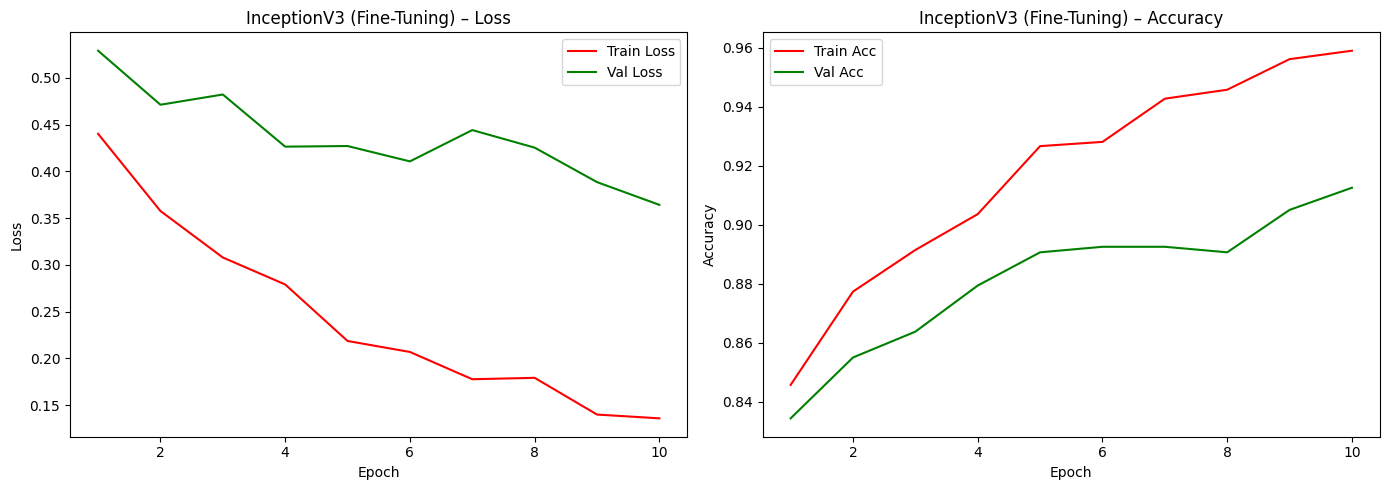

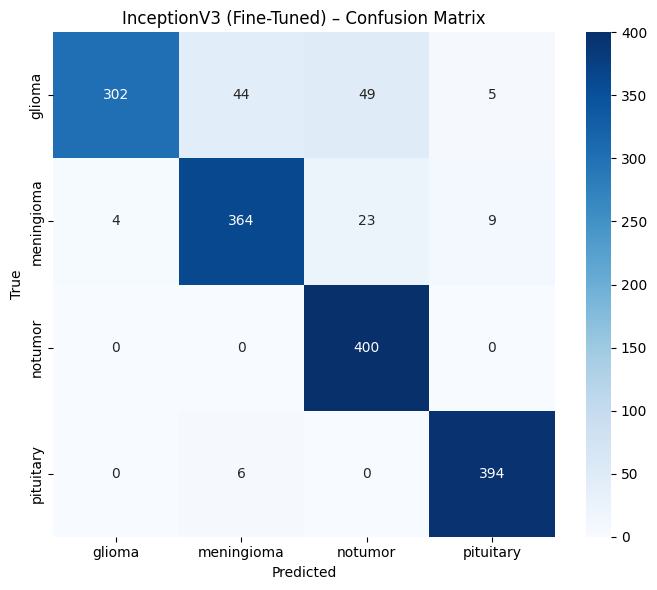

              precision    recall  f1-score   support

      glioma       0.99      0.76      0.86       400
  meningioma       0.88      0.91      0.89       400
     notumor       0.85      1.00      0.92       400
   pituitary       0.97      0.98      0.98       400

    accuracy                           0.91      1600
   macro avg       0.92      0.91      0.91      1600
weighted avg       0.92      0.91      0.91      1600



In [28]:
unfreeze_for_finetune(inception, "inception_v3")
count_trainable_params(inception)

optimizer_inc_ft = optim.Adam(
    filter(lambda p: p.requires_grad, inception.parameters()),
    lr=LR_PHASE2
)

print("\n── InceptionV3 Phase 2: Fine-Tuning ──")
inc_history_p2 = train_model_inception(
    inception, inception_train_loader, inception_test_loader,
    criterion_inc, optimizer_inc_ft,
    EPOCHS_PHASE2, DEVICE, model_name="InceptionV3-P2"
)
plot_history(inc_history_p2, model_name="InceptionV3 (Fine-Tuning)")
inc_labels, inc_preds = plot_confusion_matrix(
    inception, inception_test_loader, CLASS_NAMES, DEVICE,
    model_name="InceptionV3 (Fine-Tuned)"
)

**Hasil Perbandingan**

In [29]:
@torch.no_grad()
def get_all_preds(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        outputs = model(images.to(device))
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)


def evaluate_model_metrics(model, loader, device, model_name):
    y_true, y_pred = get_all_preds(model, loader, device)
    return {
        "Model":     model_name,
        "Accuracy":  round(accuracy_score(y_true, y_pred), 4),
        "F1-Score":  round(f1_score(y_true, y_pred, average="weighted"), 4),
        "Precision": round(precision_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "Recall":    round(recall_score(y_true, y_pred, average="weighted"), 4),
    }


results = [
    evaluate_model_metrics(efficientnet, test_loader, DEVICE, "EfficientNetB3"),
    evaluate_model_metrics(vgg16,        test_loader, DEVICE, "VGG16"),
    evaluate_model_metrics(inception,    inception_test_loader, DEVICE, "InceptionV3"),
]

results_df = pd.DataFrame(results).sort_values("Recall", ascending=False)
print(results_df.to_string(index=False))

         Model  Accuracy  F1-Score  Precision  Recall
         VGG16    0.9137    0.9114     0.9223  0.9137
   InceptionV3    0.9125    0.9106     0.9198  0.9125
EfficientNetB3    0.8862    0.8835     0.8897  0.8862


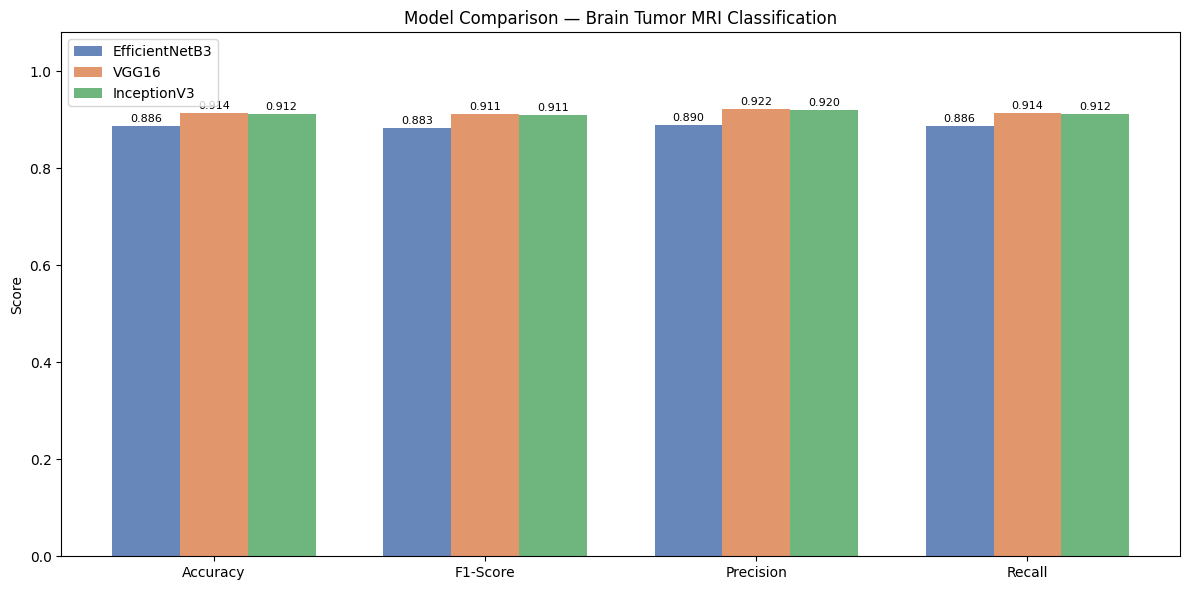

In [30]:
# ── Visual comparison bar chart ───────────────────────────────────────────────
metrics = ["Accuracy", "F1-Score", "Precision", "Recall"]
x = np.arange(len(metrics))
width = 0.25
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(12, 6))
for i, row in enumerate(results):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=row["Model"], color=colors[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Brain Tumor MRI Classification")
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
best = results_df.iloc[0]
print(f"🏆 Best model by Recall: {best['Model']}")
print(f"   Accuracy  : {best['Accuracy']}")
print(f"   F1-Score  : {best['F1-Score']}")
print(f"   Recall    : {best['Recall']}")

🏆 Best model by Recall: VGG16
   Accuracy  : 0.9137
   F1-Score  : 0.9114
   Recall    : 0.9137
